# Two-Stage Model (Die분류 → Unit집계 → Unit회귀)

**구조**:
1. Die-level position별 이진분류(OOF) → P(Y>0) 확률 산출
2. Die → Unit 집계 (WT: CV, range, min, max, median / 확률: 평균)
3. Unit-level 회귀 (집계 feature + 확률 feature)

## 1. 환경 설정 및 데이터 로드

In [1]:
# ============================================================
# 환경 설정 + 데이터 로드
# - Colab이면 Google Drive에서 코드/데이터 자동 다운로드
# - 로컬이면 ../setup.py로 패키지 설치 + 한글폰트 설정
# ============================================================
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    if not os.path.exists("/content/project/2_preprocessing/cleaning.py"):
        os.system("gdown --id 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip")
        os.system("unzip -qo /content/preprocessing.zip -d /content/project")
    sys.path.insert(0, "/content/project")
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# --- 기본 라이브러리 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from tqdm.auto import tqdm

# --- 모델 ---
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold  # OOF용 층화 K-Fold

# --- 프로젝트 공통 유틸 ---
from utils.config import PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, POSITION_COL
from utils.data import load_all, get_feat_cols, split_xs       # 데이터 로드/분할
from utils.evaluate import evaluate, postprocess                # RMSE 평가, 음수->0 클리핑
from utils.experiment import log_experiment, check_exp_id, download_from_drive  # 실험 기록

# --- 전처리 모듈 (2_preprocessing/) ---
sys.path.insert(0, os.path.join(PROJECT_ROOT, "2_preprocessing"))
from cleaning import run_cleaning              # 클리닝: 상수/저분산/중복/고결측 제거 + imputation
from outlier import run_outlier_treatment      # 이상치: Winsorization (상하위 퍼센타일 clip)
from feature_selection import run_feature_selection  # 피처 선택: Boruta + LightGBM + Null Importance

# --- 원본 데이터 로드 ---
# xs: die-level feature (174,980행 x 1,091열)  -> 1 unit = 4 dies
# ys: unit-level target (train/val/test 각각의 health 값)
xs, ys = load_all()
feat_cols = get_feat_cols(xs)          # X0~X1086 피처 컬럼명 리스트 (1,087개)
xs_dict = split_xs(xs)                 # split 컬럼 기준 train/val/test dict
ys_train = ys["train"]

패키지 설치 중: ['catboost', 'optuna', 'boruta', 'pytorch-tabnet', 'rtdl-revisiting-models']
setup 완료
Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749


In [4]:
# ============================================================
# 실험 설정 셀
# ============================================================

EXP_ID = "3-1-003"
EXP_TYPE = "베이스라인"
EXP_MEMO = ""

# --- Google Drive 파일 ID (실험 로그 저장용) ---
XLSX_GDRIVE_ID = "1IgaNh7ixgqpmH5PiwmSFbK2li6GODdew"
JSON_GDRIVE_ID = "1ycr6n5Ty_jzl4F-qQE4Cv5nS2WbIAZih"

# --- 전처리: 클리닝 ---
cleaning_params = dict(
    const_threshold=1e-6,
    missing_threshold=0.50,
    remove_duplicates=True,
    corr_threshold=0.95,
    add_indicator=True,
    indicator_threshold=0.01,
    imputation_method="median",   # "median" | "knn"
    knn_neighbors=5,              # knn일 때 이웃 수
)

# --- 전처리: 이상치 ---
outlier_params = dict(
    method="winsorize",            # "winsorize" | "iqr_clip" | "none"
    lower_pct=0.01,               # winsorize 하위 %
    upper_pct=0.99,               # winsorize 상위 %
    iqr_multiplier=1.5,           # iqr_clip IQR 배수
)

# --- Feature Selection ---
selection_params = dict(
    methods=["boruta", "lgbm_importance", "null_importance"],
    min_votes=2,
    sample_n=30000,
    boruta_params=dict(max_iter=100, max_depth=7, perc=80),
    lgbm_params=dict(threshold=0),
    null_params=dict(n_runs=10, threshold=2.0),
    rfe_params=dict(n_features_to_select=100, step=50),
    perm_params=dict(threshold=0, n_repeats=5),
    mi_params=dict(threshold=0),
)

# --- Die→Unit 집계 ---
AGG_FUNCS = ["cv", "range", "min", "max", "median"]  # die→unit 집계 함수
PROBA_AGG = "mean"                # 분류 확률 집계: "mean" | "max" | "median"

# --- Stage 1: 분류기 (이진분류 OOF) ---
clf_params = dict(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    # is_unbalanced=True,          # 클래스 불균형 자동 보정
    # scale_pos_weight=2.42,       # Y>0 가중치 (0.708/0.292)
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

# --- Stage 2: 회귀기 (unit-level 회귀) ---
reg_params = dict(
    objective="regression",          # "regression" | "poisson" | "tweedie"
    # tweedie_variance_power=1.5,   # tweedie 시 1.0~2.0
    n_estimators=10000,
    learning_rate=0.012457466004205876,
    num_leaves=49,
    max_depth=7,
    min_child_samples=245,
    subsample=0.7591420347752385,
    colsample_bytree=0.10415361830684666,
    reg_alpha=0.02321388377387803,
    reg_lambda=0.14505131037326144,
    min_split_gain=0.00010132317378668888,
    path_smooth=20.64149821542759,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

# --- OOF / Early Stopping ---
N_FOLDS = 5
CLF_EARLY_STOP = 50   # 분류기 patience
REG_EARLY_STOP = 50   # 회귀기 patience
LABEL_COL = "label_bin"

# --- 후처리 ---
CLF_THRESHOLD = 0.5   # P(Y>0) 이진 판별 임계값 (보고용)

print(f"실험번호: {EXP_ID} | Two-Stage (이진분류 OOF → Unit집계 → Unit회귀)")
print(f"집계 함수: {AGG_FUNCS} | 확률 집계: {PROBA_AGG}")
print(f"이상치: {outlier_params["method"]} | Imputation: {cleaning_params["imputation_method"]}")
print(f"회귀 objective: {reg_params["objective"]}")

download_from_drive(XLSX_GDRIVE_ID, JSON_GDRIVE_ID)
check_exp_id(EXP_ID)

실험번호: 3-1-003 | Two-Stage (이진분류 OOF → Unit집계 → Unit회귀)
집계 함수: ['cv', 'range', 'min', 'max', 'median'] | 확률 집계: mean
이상치: winsorize | Imputation: median
회귀 objective: regression
  Drive → xlsx 다운로드 중...
  완료: /content/project/4_output/experiments/experiments.xlsx
  Drive → json 다운로드 중...
  완료: /content/project/4_output/experiments/experiments.json


## 2. 전처리 (baseline 동일: 클리닝 + 이상치)

In [5]:
# --- Step 1: 클리닝 ---
# 상수/극저분산 피처 제거, 결측률 50%+ 피처 제거, 중복 컬럼 제거,
# 고상관(>0.95) 쌍 제거, median imputation, 결측 indicator 추가
# -> clean_cols: 클리닝 후 남은 피처 목록
xs_train, xs_val, xs_test, clean_cols, clean_report = run_cleaning(
    xs, feat_cols, xs_dict,
    **cleaning_params,
)

TypeError: run_cleaning() got an unexpected keyword argument 'imputation_method'

In [8]:
# --- Step 2: 이상치 처리 (Winsorization) ---
# 각 피처의 상하위 1%/99% 경계값으로 극단값을 clip
# train에서 경계값을 계산(fit)하고 val/test에도 동일하게 적용(transform)
xs_train, xs_val, xs_test, outlier_report = run_outlier_treatment(
    xs_train, xs_val, xs_test, clean_cols,
    **outlier_params,
)

NameError: name 'xs_train' is not defined

## 3. Die-level Health Merge + 이진 라벨 생성 + Position 분리

- Health(unit-level)를 die-level에 merge → 각 die가 자기 unit의 health를 가짐
- 이진 라벨: 0 vs >0 (분류기용)
- Position 1~4별 분리 → 각 position은 unit당 1개 die

In [7]:
# ============================================================
# Die-level에 Health(target) merge
# ============================================================
die_train = xs_train.merge(ys["train"], on=KEY_COL, how="left")
die_val = xs_val.merge(ys["validation"], on=KEY_COL, how="left")
die_test = xs_test.merge(ys["test"], on=KEY_COL, how="left")

assert die_train[TARGET_COL].notna().all(), "train health에 NaN!"
assert die_val[TARGET_COL].notna().all(), "val health에 NaN!"
assert die_test[TARGET_COL].notna().all(), "test health에 NaN!"
print(f"Die-level merge: train={die_train.shape}, val={die_val.shape}, test={die_test.shape}")

# -- 이진 라벨 생성: 0 vs >0 --
for df in [die_train, die_val, die_test]:
    df[LABEL_COL] = (df[TARGET_COL] > 0).astype(int)

print(f"이진 라벨 분포 (train):")
dist = die_train[LABEL_COL].value_counts().sort_index()
pct = (dist / len(die_train) * 100).round(1)
print(f"  {{k: f'{{v:,}} ({{pct[k]}}%)'  for k, v in dist.items()}}")

# ============================================================
# Position별 분리 (1 unit = 4 dies, position 1~4)
# ============================================================
positions = sorted(die_train[POSITION_COL].unique())
feat_cols_final = clean_cols

pos_data = {}
for pos in positions:
    pos_data[pos] = {
        "train": die_train[die_train[POSITION_COL] == pos].reset_index(drop=True),
        "val":   die_val[die_val[POSITION_COL] == pos].reset_index(drop=True),
        "test":  die_test[die_test[POSITION_COL] == pos].reset_index(drop=True),
    }
    n = {k: len(v) for k, v in pos_data[pos].items()}
    print(f"Position {pos}: train={n["train"]:,}, val={n["val"]:,}, test={n["test"]:,}")

print(f"Feature 수: {len(feat_cols_final)}개")

NameError: name 'xs_train' is not defined

## 3.5 Feature Selection (Boruta + LightGBM Importance + Null Importance → 투표)

die-level train 데이터에서 3가지 방법으로 feature 중요도를 평가하고, **min_votes 이상 방법에서 선택된 feature만 채택**한다.

- **Boruta**: RF 기반, shadow feature와 비교하여 통계적으로 유의미한 feature 선별
- **LightGBM Importance**: gain 기반 importance, 0 초과인 feature 선택
- **Null Importance**: target 셔플 vs 실제 importance z-score 비교, noise feature 제거

In [6]:
# --- Step 3: Feature Selection ---
# die-level train 데이터에서 3가지 방법으로 피처 중요도 판별:
#   1) Boruta: RF shadow feature 대비 통계적 유의성
#   2) LightGBM Importance: gain > 0인 피처
#   3) Null Importance: 셔플 target 대비 z-score > 2.0
# -> min_votes(2) 이상 방법에서 선택된 피처만 채택 (투표)

selected_cols, sel_report = run_feature_selection(
    X_train=die_train,
    y_train=die_train[TARGET_COL],
    feat_cols=feat_cols_final,
    **selection_params,
)

# feat_cols_final 업데이트 -> 이후 분류/회귀에서 이 피처만 사용
n_before = len(feat_cols_final)
feat_cols_final = selected_cols
print(f"\nFeature Selection 결과: {n_before} -> {len(feat_cols_final)}개")

# 투표별 피처 수 출력
if sel_report.get("vote_df") is not None:
    vote_df = sel_report["vote_df"]
    print(f"\n--- 투표 현황 ---")
    for v in sorted(vote_df["votes"].unique(), reverse=True):
        cnt = (vote_df["votes"] == v).sum()
        print(f"  {v}표: {cnt}개")
    print(f"\n상위 10 features (투표순):")
    print(vote_df.head(10).to_string(index=False))

Feature Selection 파이프라인 시작
입력 feature 수: 749
방법: ['boruta', 'lgbm_importance', 'null_importance'], 최소 투표: 2
[Boruta] max_iter=100, max_depth=7, perc=80, n_samples=30,000
  확정(confirmed): 31개
  미결(tentative): 1개
  선택 합계: 32개 / 749개
[LightGBM Importance] type=gain, threshold=0
  전체: 749개, importance=0: 48개
  선택: 701개
[Null Importance] n_runs=10, threshold=2.0
  run 10/10 완료
  z_score > 2.0: 67개 / 749개

[투표 기반 선정] min_votes=2/3
  boruta: 32개
  lgbm_importance: 701개
  null_importance: 67개
  최종 선택: 92개 / 749개

Feature Selection 완료: 749 → 92개

Feature Selection 결과: 749 -> 92개

--- 투표 현황 ---
  3표: 7개
  2표: 85개
  1표: 609개
  0표: 48개

상위 10 features (투표순):
feature  votes  boruta  lgbm_importance  null_importance
  X1007      3       1                1                1
   X718      3       1                1                1
   X817      3       1                1                1
   X846      3       1                1                1
   X725      3       1                1                1
   

## 4. Stage 1: Position별 이진분류 (OOF)

- Position별로 LightGBM 이진분류기를 K-Fold OOF로 학습
- 각 die에 대해 P(Y>0) 확률을 산출 → 이후 unit 집계 시 feature로 사용

In [7]:
def run_classification(pos_data, feat_cols, clf_params, n_folds=N_FOLDS):
    """Position별 이진분류 OOF → P(Y>0) 확률 반환"""
    all_results = {}

    for pos in sorted(pos_data.keys()):
        d = pos_data[pos]
        X_tr = d["train"][feat_cols].values
        y_tr = d["train"][LABEL_COL].values
        X_val = d["val"][feat_cols].values
        X_test = d["test"][feat_cols].values

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        oof_proba = np.zeros(len(X_tr))
        fold_models = []

        for tr_idx, val_idx in skf.split(X_tr, y_tr):
            clf = lgb.LGBMClassifier(**clf_params)
            clf.fit(
                X_tr[tr_idx], y_tr[tr_idx],
                eval_set=[(X_tr[val_idx], y_tr[val_idx])],
                callbacks=[lgb.early_stopping(CLF_EARLY_STOP, verbose=False),
                           lgb.log_evaluation(0)],
            )
            oof_proba[val_idx] = clf.predict_proba(X_tr[val_idx])[:, 1]
            fold_models.append(clf)

        train_proba = oof_proba
        val_proba = np.mean([m.predict_proba(X_val)[:, 1] for m in fold_models], axis=0)
        test_proba = np.mean([m.predict_proba(X_test)[:, 1] for m in fold_models], axis=0)

        train_acc = ((train_proba > CLF_THRESHOLD).astype(int) == y_tr).mean()
        val_acc = ((val_proba > CLF_THRESHOLD).astype(int) == d["val"][LABEL_COL].values).mean()
        print(f"  Position {pos}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

        all_results[pos] = {
            "train_proba": train_proba,
            "val_proba": val_proba,
            "test_proba": test_proba,
        }

    return all_results


print("Stage 1: Position별 이진분류 (OOF)")
print("=" * 50)
clf_result = run_classification(pos_data, feat_cols_final, clf_params)

[bin_oof] 분류 시작
  Position 1: train_acc=0.7065, val_acc=0.7073, n_classes=2
  Position 2: train_acc=0.7069, val_acc=0.7068, n_classes=2
  Position 3: train_acc=0.7065, val_acc=0.7069, n_classes=2
  Position 4: train_acc=0.7042, val_acc=0.7082, n_classes=2


## 5. Die → Unit 집계 (WT feature + 분류 확률)

- WT feature: position별 die 값을 unit 단위로 집계 (CV, range, min, max, median)
- 분류 확률: position별 P(Y>0)를 unit 단위로 평균
- 결과: unit당 1행, (feature수 × 집계함수수 + 확률 feature) 컬럼

In [8]:
def aggregate_die_to_unit(pos_data, feat_cols, clf_result, agg_funcs=AGG_FUNCS, proba_agg_func=PROBA_AGG):
    """Die-level → Unit-level 집계. WT feature + 분류 확률을 unit 단위로 합산."""
    results = {}

    for split_name in ["train", "val", "test"]:
        # 4개 position의 die 데이터를 합침
        die_frames = []
        for pos in sorted(pos_data.keys()):
            df = pos_data[pos][split_name].copy()
            # 분류 확률 컬럼 추가
            if split_name == "train":
                df["clf_proba"] = clf_result[pos]["train_proba"]
            elif split_name == "val":
                df["clf_proba"] = clf_result[pos]["val_proba"]
            else:
                df["clf_proba"] = clf_result[pos]["test_proba"]
            die_frames.append(df)

        die_all = pd.concat(die_frames, ignore_index=True)

        # --- WT feature 집계 ---
        agg_dict = {}
        for func in agg_funcs:
            if func == "cv":
                # CV = std / |mean| (0 나누기 방지)
                grp = die_all.groupby(KEY_COL)[feat_cols]
                cv_df = grp.std() / grp.mean().abs().clip(lower=1e-10)
                cv_df.columns = [f"{c}_cv" for c in feat_cols]
                agg_dict["cv"] = cv_df
            elif func == "range":
                grp = die_all.groupby(KEY_COL)[feat_cols]
                range_df = grp.max() - grp.min()
                range_df.columns = [f"{c}_range" for c in feat_cols]
                agg_dict["range"] = range_df
            else:
                grp_df = die_all.groupby(KEY_COL)[feat_cols].agg(func)
                grp_df.columns = [f"{c}_{func}" for c in feat_cols]
                agg_dict[func] = grp_df

        unit_features = pd.concat(agg_dict.values(), axis=1)

        # --- 분류 확률 집계 (평균) ---
        proba_agg = die_all.groupby(KEY_COL)["clf_proba"].agg(proba_agg_func)
        proba_agg.name = "clf_proba_agg"
        unit_features = unit_features.join(proba_agg)

        # --- health (target) 집계 (unit 내 동일값이므로 first) ---
        health = die_all.groupby(KEY_COL)[TARGET_COL].first()
        unit_features = unit_features.join(health)

        unit_features = unit_features.reset_index()
        results[split_name] = unit_features

    return results


print("Stage 2: Die → Unit 집계")
print("=" * 50)
unit_data = aggregate_die_to_unit(pos_data, feat_cols_final, clf_result)

unit_feat_cols = [c for c in unit_data["train"].columns
                  if c not in [KEY_COL, TARGET_COL]]

for sp in ["train", "val", "test"]:
    print(f"  {sp}: {unit_data[sp].shape}")
print(f"  Unit-level feature 수: {len(unit_feat_cols)}개")

[bin_oof] 회귀 시작 (분류 확률 포함)
[pos1 (val)] RMSE = 0.005751  (n=8,749, zero=6,194(70.8%))
[pos2 (val)] RMSE = 0.005749  (n=8,749, zero=6,194(70.8%))
[pos3 (val)] RMSE = 0.005750  (n=8,749, zero=6,194(70.8%))
[pos4 (val)] RMSE = 0.005745  (n=8,749, zero=6,194(70.8%))


## 6. Unit-level 회귀 + RMSE 평가

In [9]:
# ============================================================
# Unit-level LightGBM 회귀
# ============================================================
X_train = unit_data["train"][unit_feat_cols].values
X_val   = unit_data["val"][unit_feat_cols].values
X_test  = unit_data["test"][unit_feat_cols].values
y_train = unit_data["train"][TARGET_COL].values
y_val   = unit_data["val"][TARGET_COL].values
y_test  = unit_data["test"][TARGET_COL].values

print(f"학습 데이터: X={X_train.shape}, y={y_train.shape}")
print(f"검증 데이터: X={X_val.shape}, y={y_val.shape}")
print(f"테스트 데이터: X={X_test.shape}, y={y_test.shape}")

reg = lgb.LGBMRegressor(**reg_params)
reg.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(REG_EARLY_STOP, verbose=False),
               lgb.log_evaluation(0)],
)

pred_val  = postprocess(reg.predict(X_val))
pred_test = postprocess(reg.predict(X_test))

print(f"
{'=' * 50}")
print("최종 Unit-level RMSE")
print(f"{'=' * 50}")
val_rmse  = evaluate(y_val, pred_val, label="val")
test_rmse = evaluate(y_test, pred_test, label="test")

# 시각화/로깅용 DataFrame
val_merged = unit_data["val"][[KEY_COL, TARGET_COL]].copy()
val_merged["pred"] = pred_val
test_merged = unit_data["test"][[KEY_COL, TARGET_COL]].copy()
test_merged["pred"] = pred_test


[bin_oof] 최종 Unit-level RMSE
[bin_oof (val)] RMSE = 0.005742  (n=8,749, zero=6,194(70.8%))
[bin_oof (test)] RMSE = 0.008436  (n=8,749, zero=6,194(70.8%))

참고: baseline(unit-level 집계) LightGBM Val RMSE = 0.005789


## 7. 시각화

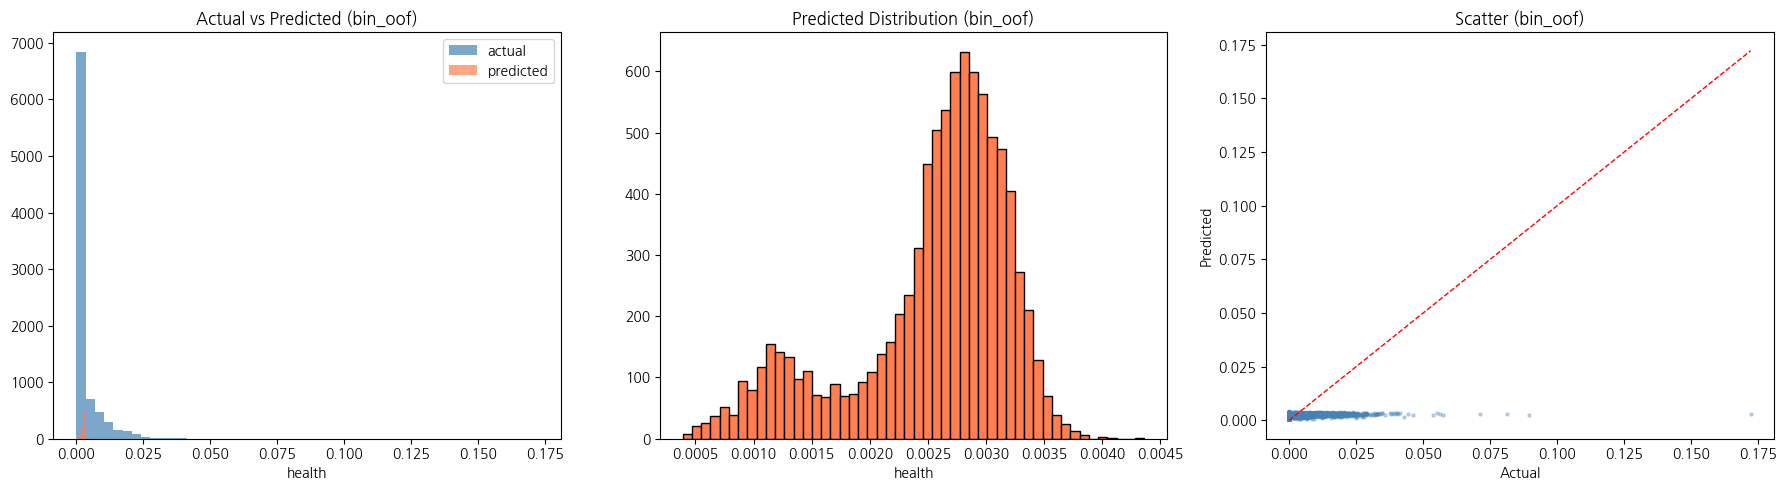


--- Position별 Val RMSE (bin_oof) ---
  Position 1: 0.005751
  Position 2: 0.005749
  Position 3: 0.005750
  Position 4: 0.005745


In [10]:
# ============================================================
# 시각화: 예측 결과 분석
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(val_merged[TARGET_COL], bins=50, alpha=0.7, label="actual", color="steelblue")
axes[0].hist(val_merged["pred"], bins=50, alpha=0.7, label="predicted", color="coral")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()
axes[0].set_xlabel(TARGET_COL)

axes[1].hist(val_merged["pred"], bins=50, color="coral", edgecolor="black")
axes[1].set_title("Predicted Distribution")
axes[1].set_xlabel(TARGET_COL)

axes[2].scatter(val_merged[TARGET_COL], val_merged["pred"],
                alpha=0.3, s=5, color="steelblue")
max_val = val_merged[TARGET_COL].max()
axes[2].plot([0, max_val], [0, max_val], "r--", linewidth=1)
axes[2].set_xlabel("Actual")
axes[2].set_ylabel("Predicted")
axes[2].set_title("Scatter")

plt.tight_layout()
plt.show()

## 8. 실험 기록

In [ ]:
# ============================================================
# 실험 결과를 xlsx(요약) + json(전 파라미터)로 저장
# ============================================================
log_experiment(
    exp_id=EXP_ID,
    exp_type=EXP_TYPE,
    best_model="LightGBM (TwoStage-Unit)",
    val_rmse=val_rmse,
    test_rmse=test_rmse,
    n_features=len(unit_feat_cols),
    memo=EXP_MEMO,
    cleaning_params=cleaning_params,
    outlier_params=outlier_params,
    feature_sel_params=selection_params,
    model_params={
        "clf": clf_params, "reg": reg_params,
        "agg_funcs": AGG_FUNCS, "proba_agg": PROBA_AGG,
        "n_folds": N_FOLDS,
        "clf_early_stop": CLF_EARLY_STOP,
        "reg_early_stop": REG_EARLY_STOP,
        "clf_threshold": CLF_THRESHOLD,
    },
    feature_cols=unit_feat_cols,
    xlsx_gdrive_id=XLSX_GDRIVE_ID,
    json_gdrive_id=JSON_GDRIVE_ID,
)


  xlsx → Drive 업로드 완료 (ID: 1IgaNh7ixgqpmH5PiwmSFbK2li6GODdew)
  json → Drive 업로드 완료 (ID: 1ycr6n5Ty_jzl4F-qQE4Cv5nS2WbIAZih)
